## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-1st_filled.csv', encoding=enc)


In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-01,2023,5,2023-04-30,40.659996,22.397246,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,2023-05-01,40.659996,22.397246,15255.0,14332.0,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-05-01,40.650186,22.350102,49.232035,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.494345,5.837251
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-01,2023,5,2023-04-30,40.677962,22.464619,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,2023-05-01,40.677962,22.464619,15351.0,14260.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-05-01,40.650186,22.450103,56.700632,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.504019,3.901367
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-05-01,2023,5,2023-04-30,40.624063,22.491569,0.253299,-0.038819,-0.281858,0.038819,0.217262,-0.067217,-0.254128,0.067217,0.043139,0.036751,0.030546,0.036751,2023-05-01,40.624063,22.491569,15195.0,14244.0,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-05-01,40.650186,22.450103,56.700632,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.504019,3.901367
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-05-01,2023,5,2023-04-30,40.624063,22.585892,0.127131,-0.143169,-0.200613,0.143169,0.139141,-0.115394,-0.199779,0.115394,0.032065,0.022881,0.030471,0.022881,2023-05-01,40.624063,22.585892,15265.0,14215.0,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-05-01,40.650186,22.550103,56.552685,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.602183,4.216068
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-05-01,2023,5,2023-04-30,40.947456,22.060378,0.533898,0.172414,-0.460370,-0.172414,0.591643,0.225081,-0.504579,-0.225081,0.030718,0.025556,0.022824,0.025556,2023-05-01,40.947456,22.060378,14754.0,14171.0,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-05-01,40.950187,22.050101,122.900567,2023-04-24,2023-04-17,2023-04-24,2023-04-17,1.398249,7.034094


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-01,2023,5,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,15255.0,14332.0,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,49.232035,0.494345,5.837251
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-01,2023,5,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,15351.0,14260.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,56.700632,0.504019,3.901367
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-05-01,2023,5,0.253299,-0.038819,-0.281858,0.038819,0.217262,-0.067217,-0.254128,0.067217,0.043139,0.036751,0.030546,0.036751,15195.0,14244.0,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,56.700632,0.504019,3.901367
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-05-01,2023,5,0.127131,-0.143169,-0.200613,0.143169,0.139141,-0.115394,-0.199779,0.115394,0.032065,0.022881,0.030471,0.022881,15265.0,14215.0,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,56.552685,2.602183,4.216068
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-05-01,2023,5,0.533898,0.172414,-0.460370,-0.172414,0.591643,0.225081,-0.504579,-0.225081,0.030718,0.025556,0.022824,0.025556,14754.0,14171.0,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,122.900567,1.398249,7.034094


In [10]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,5.0,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,15266.500000,14262.750000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,54.796496,1.026141,4.464013
1,2023-05-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,5.0,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,14510.727273,13972.181818,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,172.360332,7.549537,31.277387
2,2023-05-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,5.0,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,15051.000000,14251.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,129.586469,8.539829,24.316921
3,2023-05-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,5.0,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14701.250000,14108.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,73.469888,12.292893,36.676132
4,2023-05-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,5.0,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,14574.250000,14108.125000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,161.783456,13.509865,88.392827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-05-01,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,5.0,0.531072,0.159175,-0.434785,-0.159175,0.499631,0.147047,-0.416359,-0.147047,0.032837,0.042631,0.016784,0.042631,14662.400000,14246.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,236.853557,4.614431,66.477034
34,2023-05-01,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,5.0,0.459837,0.137113,-0.378182,-0.137113,0.461733,0.131896,-0.387717,-0.131896,0.062271,0.065290,0.054461,0.065290,14725.727273,14080.181818,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,93.955123,1.329351,31.294012
35,2023-05-01,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,5.0,0.628047,0.212817,-0.529299,-0.212817,0.638043,0.233769,-0.531265,-0.233769,0.047432,0.038162,0.026900,0.038162,14646.500000,14245.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,83.907471,0.088485,2.320277
36,2023-05-01,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,5.0,0.602195,0.296350,-0.516477,-0.296350,0.518183,0.249549,-0.446706,-0.249549,0.108254,0.108705,0.088494,0.108705,14972.000000,14220.333333,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,88.739159,7.164589,23.481618


In [11]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [12]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [13]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [15]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [16]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [17]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [18]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

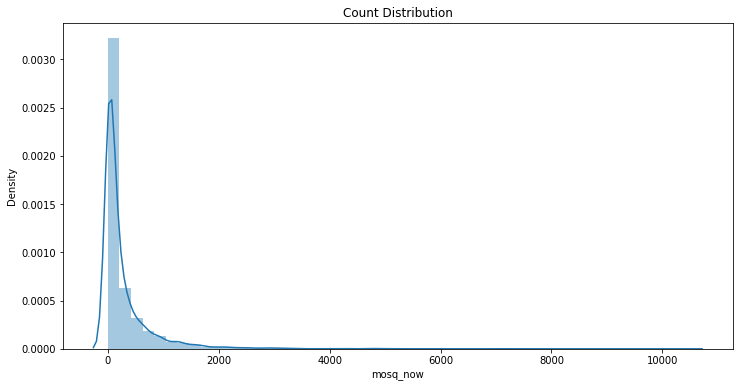

In [19]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [20]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

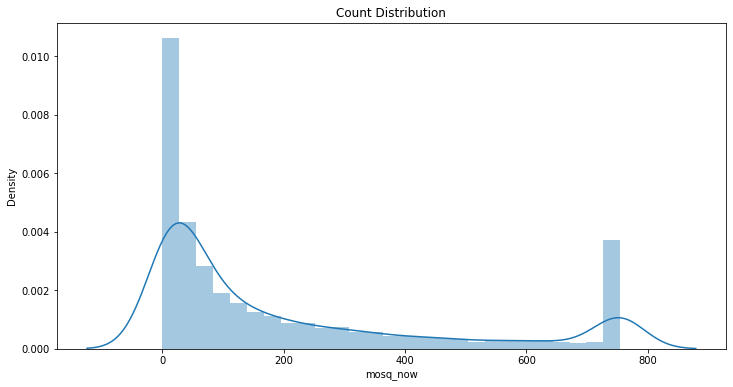

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

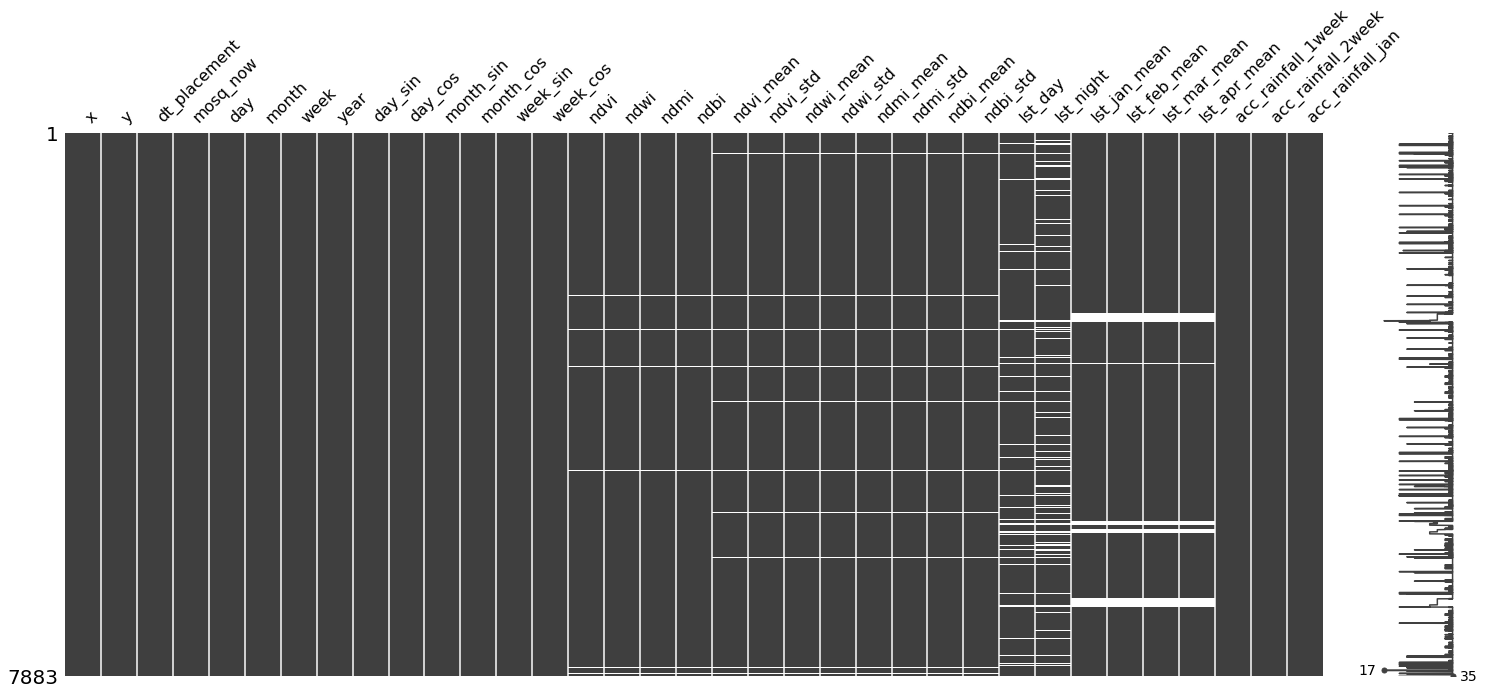

In [22]:
missingno.matrix(mosquito_data_nuts2)

In [23]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [24]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

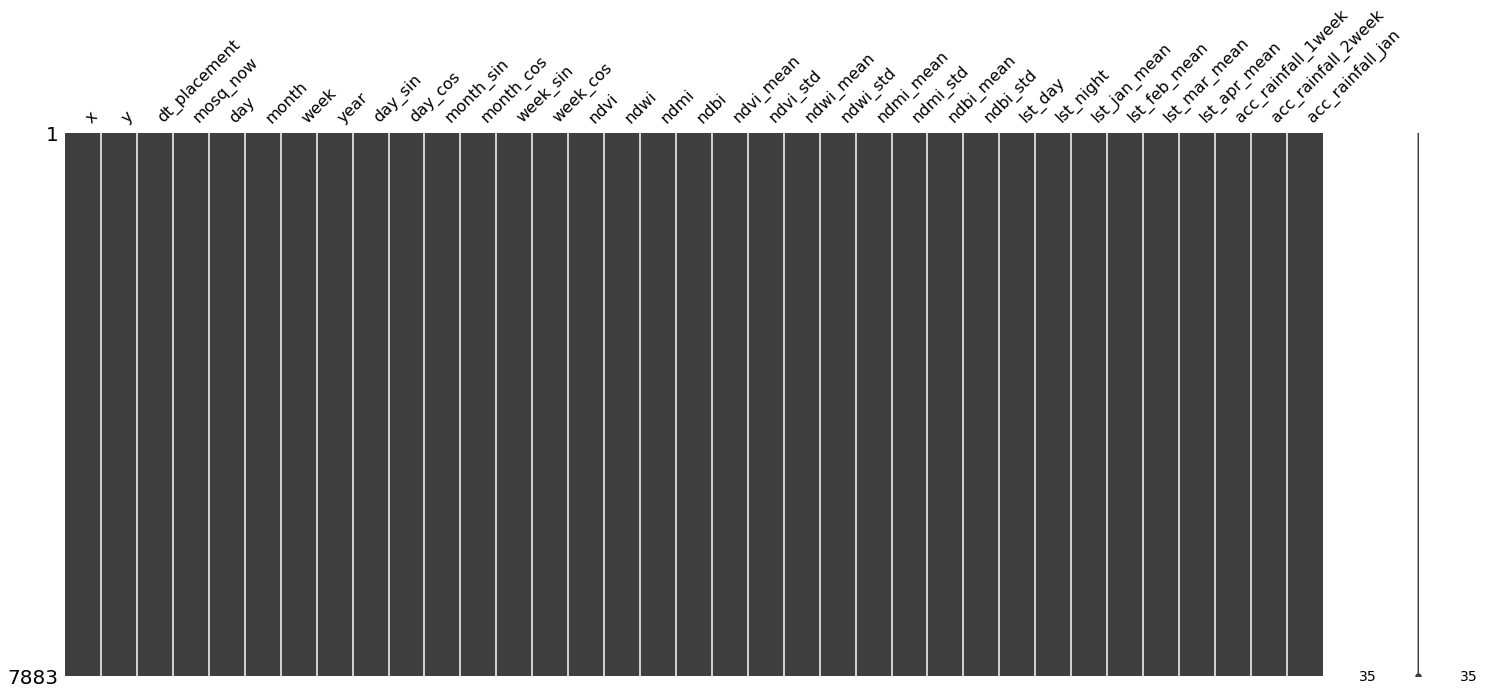

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [27]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [28]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.25776 | Val Loss: 25.21357 | Train Acc: 2.593| Val Acc: 2.025
Epoch 002: | Train Loss: 18.70602 | Val Loss: 26.06468 | Train Acc: 2.269| Val Acc: 2.095
Epoch 003: | Train Loss: 18.33340 | Val Loss: 24.65330 | Train Acc: 2.183| Val Acc: 1.961
Epoch 004: | Train Loss: 17.97626 | Val Loss: 23.98612 | Train Acc: 2.133| Val Acc: 1.922
Epoch 005: | Train Loss: 17.74889 | Val Loss: 23.72964 | Train Acc: 2.092| Val Acc: 1.915
Epoch 006: | Train Loss: 17.52364 | Val Loss: 23.59278 | Train Acc: 2.053| Val Acc: 1.920
Epoch 007: | Train Loss: 17.29705 | Val Loss: 23.51792 | Train Acc: 2.028| Val Acc: 1.903
Epoch 008: | Train Loss: 16.96989 | Val Loss: 23.50311 | Train Acc: 1.992| Val Acc: 1.929
Epoch 009: | Train Loss: 17.14320 | Val Loss: 23.45116 | Train Acc: 2.055| Val Acc: 2.004
Epoch 010: | Train Loss: 16.77573 | Val Loss: 23.58055 | Train Acc: 1.990| Val Acc: 1.978
Epoch 011: | Train Loss: 16.69920 | Val Loss: 23.50495 | Train Acc: 1.998| Val Acc: 1.980
Epoch 012:

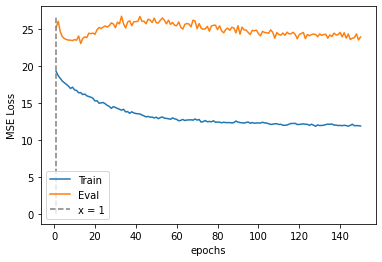

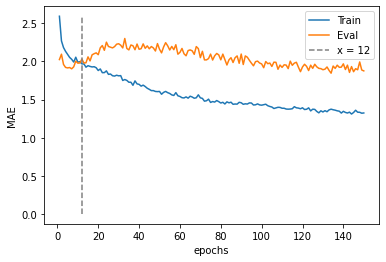

In [29]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [30]:
metrics(train, test, threshold=30)

MAE on train set:  134.30591734525234
min prediction: 1
max prediction: 1697

MAE on test set:  148.62941961861517
Error ⩽ 30: 24.88 %
min prediction: 1
max prediction: 1467


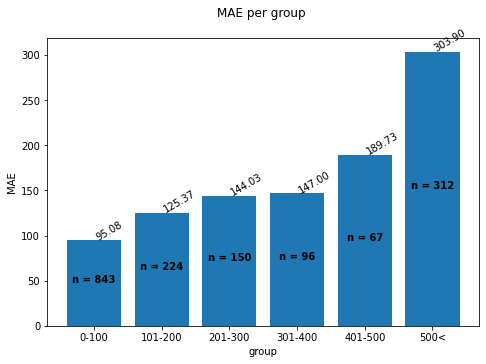

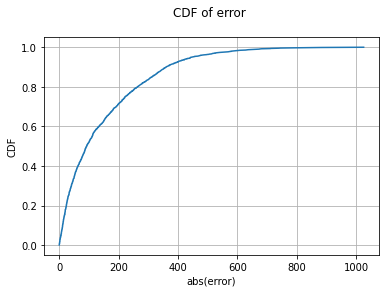

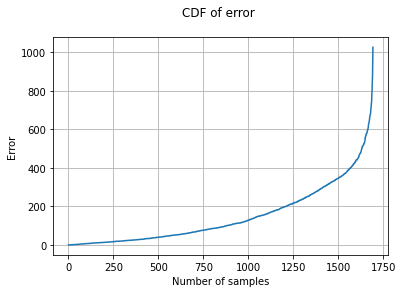

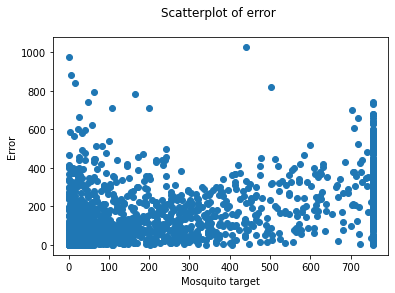

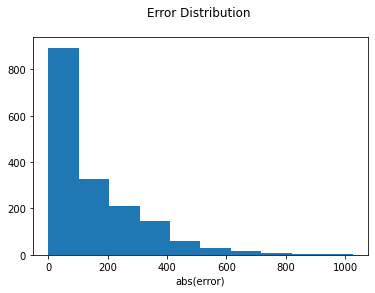

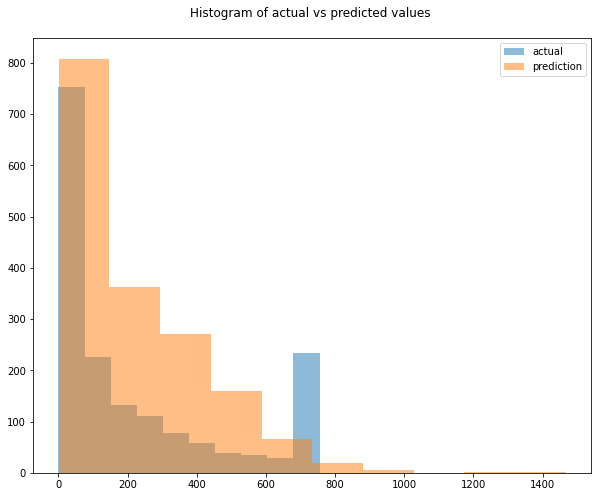

In [31]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.61040 | Val Loss: 1.95616 | Train Acc: 1.563| Val Acc: 1.633
Epoch 002: | Train Loss: 13.50364 | Val Loss: 3.77689 | Train Acc: 1.532| Val Acc: 1.633
Epoch 003: | Train Loss: 13.54965 | Val Loss: 5.72744 | Train Acc: 1.547| Val Acc: 2.633
Epoch 004: | Train Loss: 13.49584 | Val Loss: 2.70750 | Train Acc: 1.540| Val Acc: 1.633
Epoch 005: | Train Loss: 13.23358 | Val Loss: 4.72218 | Train Acc: 1.515| Val Acc: 2.633
Epoch 006: | Train Loss: 13.40725 | Val Loss: 3.98251 | Train Acc: 1.535| Val Acc: 1.633
Epoch 007: | Train Loss: 13.34335 | Val Loss: 5.00888 | Train Acc: 1.543| Val Acc: 2.633
Epoch 008: | Train Loss: 13.43024 | Val Loss: 2.00908 | Train Acc: 1.560| Val Acc: 1.633
Epoch 009: | Train Loss: 13.50970 | Val Loss: 4.24555 | Train Acc: 1.544| Val Acc: 1.633
Epoch 010: | Train Loss: 13.20337 | Val Loss: 4.25122 | Train Acc: 1.506| Val Acc: 1.633
Epoch 011: | Train Loss: 13.11175 | Val Loss: 3.99856 | Train Acc: 1.509| Val Acc: 1.633
Epoch 012: | Train Lo

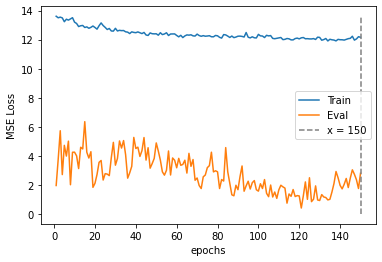

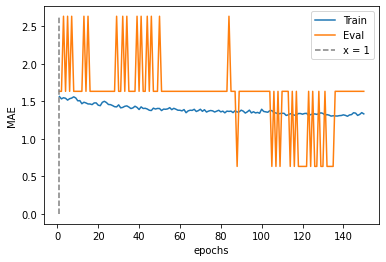

In [32]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [34]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [35]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [36]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [37]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [38]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

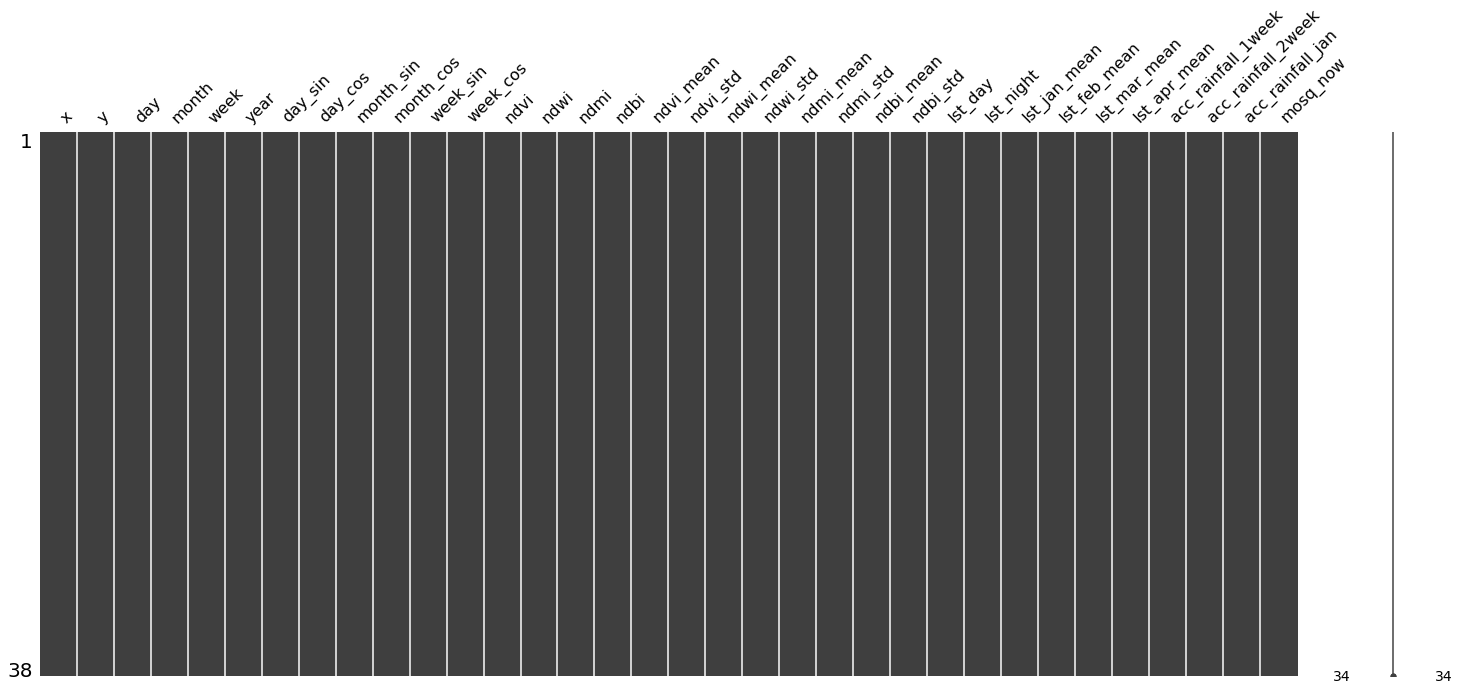

In [39]:
missingno.matrix(dataset_mamoth)

In [40]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [41]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [42]:
predictions = give_predictions(model, dataset_mamoth)

In [43]:
mosqutio_predictions['mosq_pred'] = predictions

In [44]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-05-01,202
1,21.940791,40.977027,2023-05-01,40
2,22.891980,40.656030,2023-05-01,161
3,23.982527,40.915102,2023-05-01,186
4,23.691080,40.495934,2023-05-01,54
...,...,...,...,...
33,23.828106,40.110264,2023-05-01,48
34,23.388058,41.313484,2023-05-01,115
35,22.146700,40.822940,2023-05-01,37
36,22.723020,40.753567,2023-05-01,55


In [45]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-1st.csv', index = False)